# DDPM and Distillation on MNIST


## Instruction
Similar to Assignment 1, we provided you a code starter, so you wn't need to start frm scrach. You are supposed to use this code starter in oprder to complete the assignment as follows:
- Read the code provided fpr each task carefully
- Complete the missing parts
- Run the code and get/print necessary output for each task/question
- Save the notebook and submit the final file

In [ ]:
### Global Setup & Config
import math, time, random, os, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 24   # I set my own previous assignments' seed
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

CFG = {
    "train_subset": 10000,
    "batch_size": 128,
    "epochs": 250,
    "lr": 2e-3,
    "timesteps": 1000,
    "img_size": 28,
    "save_dir": "./outputs"
}
os.makedirs(CFG["save_dir"], exist_ok=True)
print('Device:', device)
print('Config:', CFG)


Device: cuda
Config: {'train_subset': 10000, 'batch_size': 128, 'epochs': 250, 'lr': 0.002, 'timesteps': 1000, 'img_size': 28, 'save_dir': './outputs'}



## Part 1 — Setup & Baseline

### **Task 1 — MNIST Setup**
**Do:** Load MNIST (use **10,000** train images + full test set). Normalize to **[-1,1]**. Show a small grid of samples.  
**Q:** Why is MNIST good for generative modeling (especially for compex generative models like diffusion models)? What are its modern limitations?
<div dir='rtl' align='justify'>

MNIST برای مدل های مولد مناسب است چون داده های ساده ای دارد و باعث میشود آموزش مدل ها سریع و بدون نیاز به سخت‌افزار سنگین انجام بشه. تعداد داده‌ها نیز زیاد است و شکل عددها واضح و مشخص است پس مدل ها راحت تر یاد میگیرندش. به همین دلیل معمولا به عنوان یک  baseline در نظر میگیرندش و قبل از این‌که مد‌لها روی دیتا های سخت تر آموزش ببینند روی MNIST  تست میشن تا ببینند دقت خوبی میگیرن یا نه چون اکثر مدل های مدل عملکرد خوبی رو MNIST داشتند.
این داده امروزه محدودیت زیادی هم داره : مثلا آموزش همه انواع مدل های مولد روی این داده خیلی راحت شده و تقریبا همه مدل ها نتایج خوبی بدست میارند که مقایسه نقاط قوت و ضعف اون مدلهارو سخت میکنه. نمونه ها تنوع پایینی دارند و فقط اعداد  ۰ تا ۹، سیاه سفید، و در مرکز تصویر هستند و رزولوشن خیلی کمی دارد که شرایط واقعی تولید تصاویر باکیفیت بالا را نشان نمیدهد. چون دیتای ساده ایه نتیجه خوب روی اون به میعنی نتیجه خوب روی داده های دیگه نیست. برای همین  بیشتر به عنوان یک مثال ساده و آموزشی استفاده می‌شود تا یک معیار جدی پژوهشی.

</div>

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


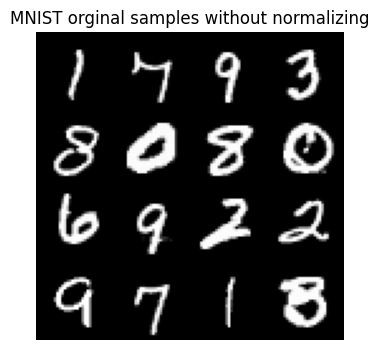

In [ ]:
### Task 1: MNIST Data
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Subset
import random, os

transform = transforms.Compose([
    transforms.ToTensor(), # gives pixel values in [0,1]
    transforms.Normalize((0.5,), (0.5,)) # Normalizes the data that is in [0,1] to [-1,1]
])

train_ds_full = dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

test_ds = dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

idxs = list(range(len(train_ds_full)))
random.shuffle(idxs)
train_subset = Subset(train_ds_full, idxs[:CFG["train_subset"]])

train_loader = DataLoader(train_subset, batch_size=CFG["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = next(iter(train_loader))
grid_path = os.path.join(CFG["save_dir"], "mnist_samples.png")
utils.save_image((x0[:16]*0.5+0.5), grid_path, nrow=8)

# make a grid of the first 16 images
from torchvision.utils import make_grid

grid = make_grid((x0[:16]*0.5+0.5), nrow=4)

plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("MNIST orginal samples without normalizing")
plt.show()


### **Task 2 — Diffusion Forward Process**
**Do:** Implement the forward (noising) process with a **linear beta** schedule for `T = CFG["timesteps"]`. Visualize frames at `t ∈ {0, T/4, T/2, 3T/4, T}`.  
**Q:** Why add Gaussian noise **gradually** instead of all at once?

<div dir='rtl' align='justify'>

اگر نویز گوسی رو به یکباره و در یک مرحله اضافه کنیم (یعنی مثل denosing score matching)، اگر انحراف معیار کوچک باشد، مدل فقط یاد میگیرد تا یک نویز کم رو از دیتا پاک کنه که خب در تولید تصویر از نویز محض به مشکل میخوره. همچنین اگه انحراف معیار بزرگ باشه مدل نمیتونه یاد بگیره چجوری از اون نویز عکس ریکاوری کنه. ولی اگه نویز به صورت تدریجی اضافه بشه وضوح عکس مرحله به مرحله کم میشه. در مرحله های اول هنوز یکم از ارقام مشخص اند، در اواسط بلوری و در اخر مثل یه نویز خالص اند. این یعنی مدل به صورت مرحله به مرحله میبینه که تصویر چجوری خراب شده و نویزی شده نه فقط یه مرحله نویز راحت یا شدید گه بعدا نتونه از اونا سمپل جنریت کنه. پس مدل در هر مرحله یه اطلاعات مهمی داره و به صورت مرحله به مرحله میتونه از نویز خالص به تصویری که یک رقم دست نوشته رو نشون میده برگرده.

</div>

In [ ]:
### Task 2: Forward (q)
def make_beta_schedule(T, start=1e-4, end=0.02):
    return torch.linspace(start, end, T, device=device)

T = CFG["timesteps"]
betas = make_beta_schedule(T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1,0), value=1.0)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    sqrt_om = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
    return sqrt_ac * x0 + sqrt_om * noise

def show_noising_example(batch=None):
    if batch is None:
        batch, _ = next(iter(train_loader))
    x0 = batch.to(device)[:8]
    steps = [0, T//4-1, T//2-1, 3*T//4-1, T-1]
    imgs = []
    for s in steps:
        t = torch.full((x0.size(0),), s, device=device, dtype=torch.long)
        xt = q_sample(x0, t)
        imgs.append(xt.cpu())
    grid = torch.cat(imgs, dim=0)
    path = os.path.join(CFG["save_dir"], "noising_grid.png")
    utils.save_image((grid+1)/2, path, nrow=x0.size(0))
    return path, steps, grid



In [ ]:
path, steps, grid = show_noising_example()

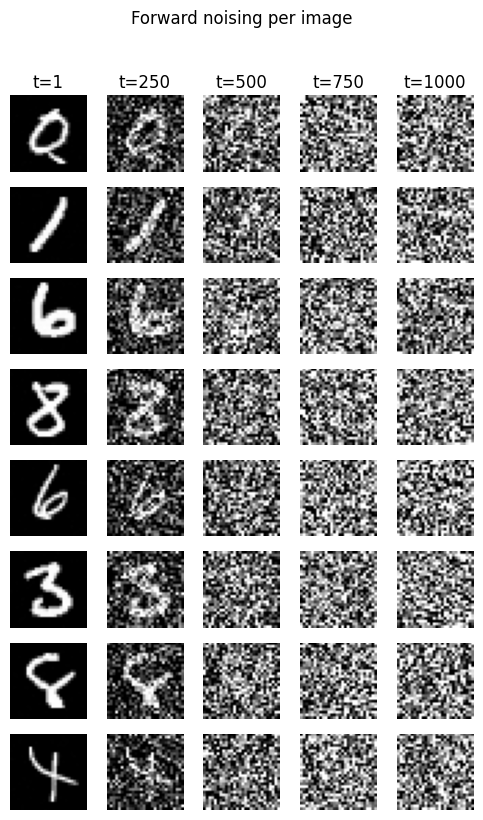

In [ ]:
n_steps = len(steps)
total= grid.shape[0]
n_images = total // n_steps

# de-normalize from [-1,1] to [0,1] just for plot
imgs = ((grid + 1) / 2).clamp(0,1)

imgs = imgs.view(n_steps, n_images, 1, 28, 28).permute(1,0,2,3,4)
plt.figure(figsize=(n_steps, n_images))
for i in range(n_images):
    for j in range(n_steps):
        ax = plt.subplot(n_images, n_steps, i*n_steps + j + 1)
        ax.imshow(imgs[i,j,0], cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"t={steps[j]+1}")
plt.suptitle("Forward noising per image", y=1.02)
plt.tight_layout()
plt.show()



## Part 2 — Train a Lightweight Diffusion Model

### **Task 3 — Small Denoising Network**
**Do:** Implement a small **UNet-like** denoiser (≤ ~2M params) with **timestep embeddings**. Train for ~**2–5 epochs** and print loss.
<div dir='rtl' align='justify'>

از اونجایی که با ایپاک های پایین تصاویر تولید شده اصلا وضوح خوبی نداشتند و نویز بودند، با ایپاک 250 مدل رو آموزش دادم.
</div>

**Q:** Why do we use **timestep embeddings**?

<div dir='rtl' align='justify'>

ما از timestep embeddings استفاده می‌کنیم چون هر تصویر نویزی بسته به مرحله t مقدار نویز متفاوتی دارد. شبکه‌ denoiser باید بداند در این مرحله چه مقدار نویز اضافه شده تا بتواند همان مقدار را حذف کند. این یعنی در مراحل اولیه که تصویر تقریبا تمیز است شبکه فقط اصلاحات کوچک انجام می‌دهد، و در مراحل پایانی که تصویر تقریبا نویز خالص است شبکه باید اصلاحات بزرگتری یاد بگیرد. بدون داشتن اطلاعات مرحله‌ زمانی شبکه نمی‌تواند تشخیص دهد که باید نویز کمی بردارد یا تقریبا همه‌ نویز را حذف کند و یادگیری ناپایدار میشود.

</div>


In [ ]:

### Task 3: Denoiser
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / half)
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.gn1 = nn.GroupNorm(1, out_ch)
        self.gn2 = nn.GroupNorm(1, out_ch)
    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.conv1(x)))
        t = self.time_mlp(t_emb)[:, :, None, None]
        h = h + t
        h = F.silu(self.gn2(self.conv2(h)))
        return h

class TinyUNet(nn.Module):
    def __init__(self, time_dim=64, base=32):
        super().__init__()
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(time_dim), nn.Linear(time_dim, time_dim), nn.SiLU())
        self.inc = nn.Conv2d(1, base, 3, padding=1)
        self.down1 = Block(base, base*2, time_dim)
        self.pool = nn.AvgPool2d(2)
        self.mid = Block(base*2, base*2, time_dim)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = Block(base*2, base, time_dim)
        self.outc = nn.Conv2d(base, 1, 1)
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x1 = F.silu(self.inc(x))
        x2 = self.pool(self.down1(x1, t_emb))
        x3 = self.mid(x2, t_emb)
        x4 = self.up(x3)
        x5 = self.up1(x4, t_emb)
        out = self.outc(x5)
        return out

ddpm = TinyUNet().to(device)
params = sum(p.numel() for p in ddpm.parameters())

optimizer = torch.optim.AdamW(ddpm.parameters(), lr=CFG["lr"])

def p_losses(model, x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    pred_noise = model(xt, t)
    return F.mse_loss(pred_noise, noise)

def train_denoiser(model, epochs=CFG["epochs"]):
    model.train()
    training_time = 0
    for ep in range(1, epochs+1):
        t0 = time.time()
        losses = []
        for x, _ in train_loader:
            x = x.to(device)
            t = torch.randint(0, T, (x.size(0),), device=device).long()
            loss = p_losses(model, x, t)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            losses.append(loss.item())
        training_time += time.time()-t0
        print(f"Epoch {ep}/{epochs} | loss={np.mean(losses):.4f} | time={time.time()-t0:.1f}s")
    return model, training_time

# train models with enough number of epochs
epochs = int(CFG['epochs'])
trained_model, training_time = train_denoiser(ddpm, epochs)

Epoch 1/250 | loss=1.0021 | time=4.4s
Epoch 2/250 | loss=0.7931 | time=5.8s
Epoch 3/250 | loss=0.3521 | time=5.3s
Epoch 4/250 | loss=0.1691 | time=6.3s
Epoch 5/250 | loss=0.1235 | time=4.5s
Epoch 6/250 | loss=0.1057 | time=2.9s
Epoch 7/250 | loss=0.0937 | time=4.0s
Epoch 8/250 | loss=0.0830 | time=3.0s
Epoch 9/250 | loss=0.0785 | time=2.9s
Epoch 10/250 | loss=0.0721 | time=2.9s
Epoch 11/250 | loss=0.0696 | time=4.0s
Epoch 12/250 | loss=0.0642 | time=2.9s
Epoch 13/250 | loss=0.0634 | time=2.9s
Epoch 14/250 | loss=0.0674 | time=2.8s
Epoch 15/250 | loss=0.0581 | time=3.6s
Epoch 16/250 | loss=0.0570 | time=3.1s
Epoch 17/250 | loss=0.0553 | time=3.0s
Epoch 18/250 | loss=0.0519 | time=2.9s
Epoch 19/250 | loss=0.0522 | time=3.4s
Epoch 20/250 | loss=0.0503 | time=3.4s
Epoch 21/250 | loss=0.0501 | time=2.9s
Epoch 22/250 | loss=0.0489 | time=2.9s
Epoch 23/250 | loss=0.0494 | time=3.2s
Epoch 24/250 | loss=0.0471 | time=3.6s
Epoch 25/250 | loss=0.0463 | time=2.9s
Epoch 26/250 | loss=0.0454 | time=

- Show sample reconstructions at different timesteps.


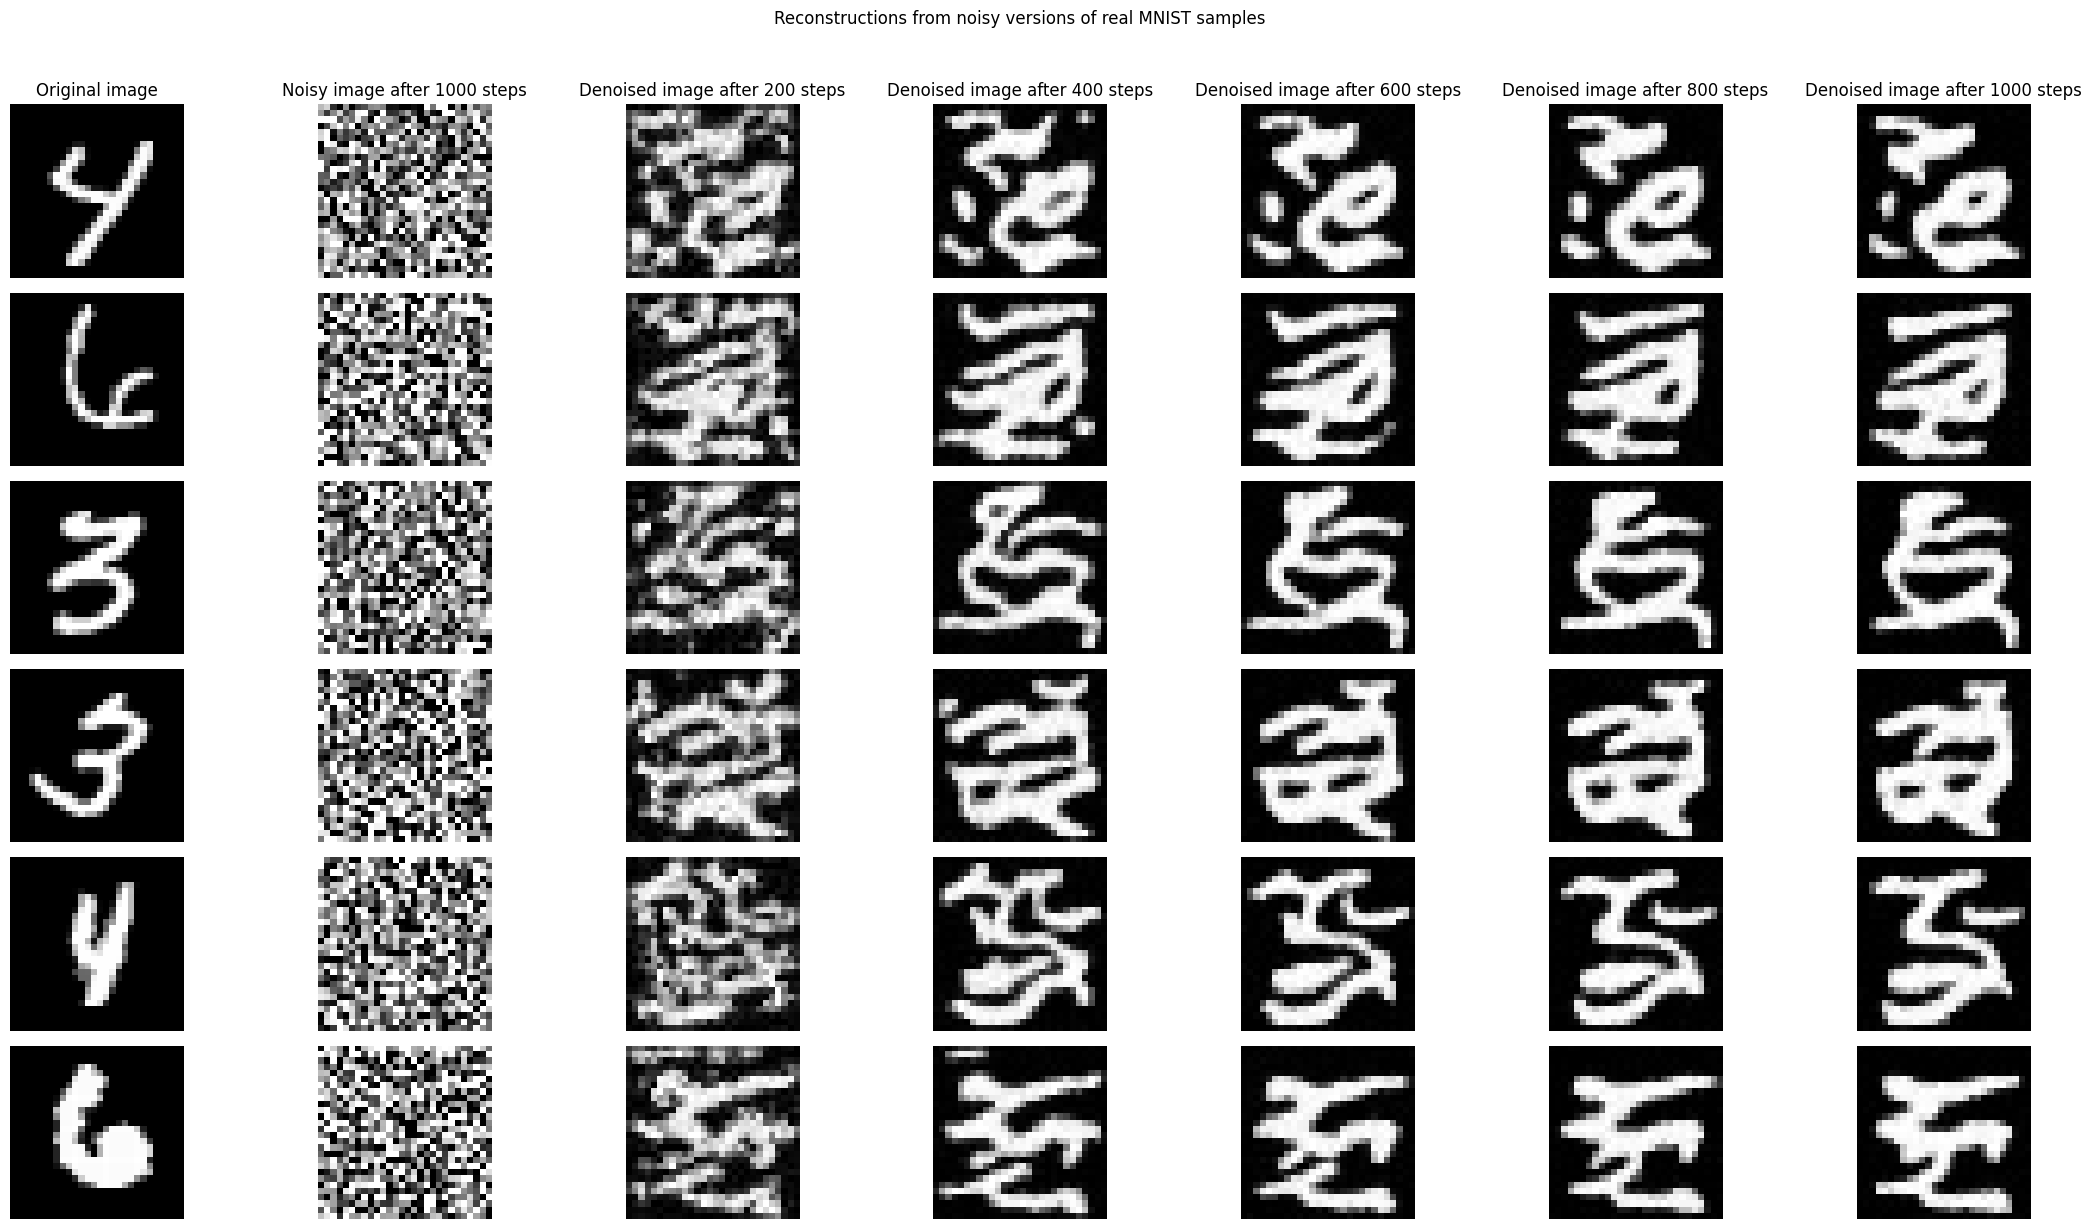

In [ ]:
@torch.no_grad()
def p_sample(model, xt, t):
    beta_t = betas[t][:, None, None, None]
    sqrt_one_minus_ac = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
    pred_noise = model(xt, t)
    x0_hat = (xt - sqrt_one_minus_ac * pred_noise) / torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    coef1 = torch.sqrt(alphas_cumprod_prev[t])[:, None, None, None] * beta_t / (1 - alphas_cumprod[t])[:, None, None, None]
    coef2 = torch.sqrt(alphas[t])[:, None, None, None] * (1 - alphas_cumprod_prev[t])[:, None, None, None] / (1 - alphas_cumprod[t])[:, None, None, None]
    mean = coef1 * x0_hat + coef2 * xt
    if (t == 0).all():
        return mean
    noise = torch.randn_like(xt)
    var = beta_t
    return mean + torch.sqrt(var) * noise


x0, _ = next(iter(train_loader))

n_images = 6
x0 = x0.to(device)[:n_images]

n_steps  = 5

# collect reconstructions
x0_hat = q_sample(x0, torch.full((n_images,), T-1, device=device, dtype=torch.long))
recons = [x0, x0_hat]

for _ in range(n_steps):

    for s in reversed(range(T//n_steps)):
        t = torch.full((n_images,), s, device=device, dtype=torch.long)
        x0_hat = p_sample(trained_model, x0_hat, t)

    x0_hat = x0_hat.clamp(-1, 1)
    recons.append(x0_hat.to(device))

recons = torch.stack(recons, dim=1)

# plot each row one digit, columns reconstructions from noisy inputs
plt.figure(figsize=(4.5*n_steps, 2*n_images))

titles = ['Original image',
          'Noisy image after 1000 steps',
          ]+[f'Denoised image after {T//n_steps*i} steps' for i in range(1,n_steps+1)]

for i in range(n_images):
    for j in range(n_steps+2):
        ax = plt.subplot(n_images, n_steps+2, i*(n_steps+2) + j + 1)
        img = ((recons[i,j,0] + 1)/2).clamp(0,1).cpu().numpy()
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if i == 0:
           ax.set_title(titles[j])

plt.suptitle("Reconstructions from noisy versions of real MNIST samples", y=1.02)
plt.tight_layout()
plt.show()



### **Task 4 — Generate Samples**
**Do:** Implement the reverse process (DDPM sampling). Generate **10** samples and save a grid.  
**Q:** Are samples **diverse** and **recognizable**?
<div dir='rtl' align='justify'>

نمونه های تولید شده تا حدی متنوع هستند و از بیشتر عددها تولید شده ولی همچنان بعضی تصاویر رقم خاصی را نمایش نمیدهد. با این حال تصاویر خیلی شارپ هستند و مثل تصاویر تولید شده با بعضی مدل های گذشته بلور یا هاله و نویز در تصویر دیده نمیشود. همچنین خیلی از ارقام مانند 7، 2، 0 و 6 واقعی و مشخص هستند. احتمالا مدل با تعداد ایپاک بیشتر و یا شبکه پیچیده تر موفق به تولید تصاویر بهتر بشود.

</div>

In [ ]:

# === Task 4: Sampling (p) ===
@torch.no_grad()
def p_sample(model, xt, t):
    beta_t = betas[t][:, None, None, None]
    sqrt_one_minus_ac = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
    pred_noise = model(xt, t)
    x0_hat = (xt - sqrt_one_minus_ac * pred_noise) / torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    coef1 = torch.sqrt(alphas_cumprod_prev[t])[:, None, None, None] * beta_t / (1 - alphas_cumprod[t])[:, None, None, None]
    coef2 = torch.sqrt(alphas[t])[:, None, None, None] * (1 - alphas_cumprod_prev[t])[:, None, None, None] / (1 - alphas_cumprod[t])[:, None, None, None]
    mean = coef1 * x0_hat + coef2 * xt
    if (t == 0).all():
        return mean
    noise = torch.randn_like(xt)
    var = beta_t
    return mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop(model, n=10):
    model.eval()
    xt = torch.randn(n, 1, CFG["img_size"], CFG["img_size"], device=device)
    for s in reversed(range(T)):
        t = torch.full((n,), s, device=device, dtype=torch.long)
        xt = p_sample(model, xt, t)
    x_gen = xt.clamp(-1, 1)
    path = os.path.join(CFG["save_dir"], "samples_ddpm.png")
    utils.save_image((x_gen+1)/2, path, nrow=5)
    return path, x_gen

# generate new samples, save and print them
path, samples = p_sample_loop(trained_model, n=10)
print("Saved samples to:", path)


Saved samples to: ./outputs/samples_ddpm.png


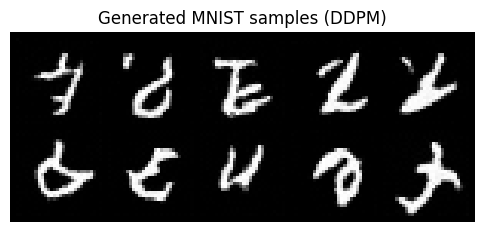

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Visualize samples
grid = make_grid((samples + 1) / 2, nrow=5)   # back to [0,1] for display
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Generated MNIST samples (DDPM)")
plt.show()


## Part 3 — Evaluation

### **Task 5 — Lightweight Quantitative Evaluation**
1) Generate 1000 Samples

2) Train a tiny MNIST classifier (2–3 conv layers, 1–2 epochs). Report **accuracy on generated samples**.  

   Generated set — diversity entropy: 2.166
      |digits|Pred label counts|
      |-----|-----------------|
      |0|	84|
      |1|	29|
      |2|	142|
      |3|	74|
      |4|	126|
      |5|	82|
      |6|	73|
      |7|	85|
      |8|	241|
      |9|	64|
  
  <div dir='rtl' align='justify'>

  جدول بالا نشان میدهد مدل توانسته از همه ارقام نمونه تولید کنه ولی تنوع و توزیع آن نامتعادل است. البته از طریق این جدول به صورت دقیق نمیتوان گفت چون بعضی از تصاویر ممکن است هیچ رقمی را نشان ندهد و به سختی در یکی از کلاسها گنجانده شده باشد. با این حال تنوع خیلی متعادل نیست و تعداد بعضی رقم ها مثل 8 خیلی بالا و برخی مثل 1 خیلی پایین است. diversity entropy معیار مناسبی برای سنجیدن تنوع نمونه ها توسط یک classifier است که مقدار بدست آمده آن 2.166 است که نسبتا از مقدار ماکسیمم آن یعنی تقریبا 2.302 پایین تر است و این هم تنوع متوسط به پایین نمونه ها را تایید میکند.
  </div>

3) Compute the same **sample quality metrics** used to evaluate generated samples as in Assingments 3 & 4 (Hwk 4: Task 7) for the genrated smaple of your trained diffusion model here, complete your table from Assignment 4 with them, and comment on the results.

- Based on the metric, how does the diffusion model compare?

  |Model|IS|FID|KID|
  |---|---|---|---|
  |NICE|4\.598|197\.052|492\.153|
  |GAN|7\.087|30\.437|97\.704|
  |EBM with Mapping|4\.9|219\.84|543\.555|
  |EBM with PCA|7\.367|45\.901|140\.373|
  |GMM|4\.76|208\.392|517\.162|
  |NADE|4\.389|181\.151|422\.694|
  |VAE|7\.24|110\.359|318\.398|
  |**DDPM**|**6\.748**|**235\.744**|**3227\.831**|



  <div dir='rtl' align='justify'>


  جدول نشان میدهد که DDPM در معیار IS = 6.748 عملکرد متوسط رو به خوبی دارد. از NICE، NADE، GMM و EBM with Mapping بهتر است چون تصاویری که تولید کرده بر خلاف این مدلها شارپی  و وضوح خوبی دارند و هاله نویزی یا بلوری ندارند. اما نسبت به بهترین‌ها یعنی EBM with PCA (7.367)، GAN (7.087) و VAE (7.24) کمی ضعیف تر عمل کرده. ولی نکته اصلی اینجاست که در دو معیار دیگر که فاصله توزیع رو میسنجند(FID = 235.744 و KID = 3227.831، DDPM) ، عملکرد خوبی نداشته  و بدترین نتیجه را دارد و حتی از مدلهای ضعیف تر از نظر IS مثل NICE، NADE یا GMM هم نتیجه بدتری  گرفته مثلا FID آن تقریبا دو برابر VAE و هفت برابر GAN است. این نشان می‌دهد که هرچند DDPM توانسته تنوع قابل قبول با وضوح، شارپی و تنوع بالا  ایجاد کند، اما کیفیت و شباهت آماری تصاویرش با داده‌ های واقعی  MNIST بسیار پایین است. این مسئله از مشاهده نمونه های تولید شده هم مشخص بود چون خیلی از ارقام با این که خطوط واضح و و متنوعی بودند ولی شبیه به هیچ رقم خاصی نبودند و صرفا خطوط بی معنی بودند. به طور کلی، در این پیاده‌سازی  DDPM نسبت به همه مدلهای دیگر از نظر FID/KID عملکرد ضعیف تری دارد.
  </div>

#### Train a tiny MNIST classifier

In [ ]:
### Task 5: Tiny Classifier for Evaluation
class TinyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv_classifier = nn.Sequential(
            # first conv 28x28 to 14x14
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # second conv 14x14 to 7x7
            nn.Conv2d(16, 6, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(6),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            # fully connected layer
            nn.Linear(6 * 7 * 7, num_classes),
        )

    def forward(self, img):
        logit = self.conv_classifier(img)
        return logit # logits

def train_tiny_classifier(model, epochs=2):

    model.train()
    for ep in range(1, epochs+1):
        t0 = time.time()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        # quick test accuracy
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb).argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.numel()
        acc = correct / max(1, total)
        print(f"Epoch {ep}/{epochs} | loss={np.mean(losses):.4f} | test acc={acc*100:.2f}% | {time.time()-t0:.1f}s")
        model.train()
    model.eval()
    return model


@torch.no_grad()
def evaluate_generated_with_classifier(clf, imgs):

    clf.eval()
    logits = clf(imgs.to(device))
    probs = logits.softmax(dim=1)
    preds = probs.argmax(dim=1).cpu()

    # diversity entropy of predicted labels
    N = probs.size(0)
    hist = torch.bincount(preds, minlength=10).float() / max(1, N)
    # add a tiny epsilon for numerical stability
    eps = 1e-8
    diversity_entropy = float(-(hist * (hist+eps).log()).sum().cpu())


    return preds, diversity_entropy

# train classifier, obtain and print the results

# Train the classifier
clf = TinyCNN().to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
clf = train_tiny_classifier(clf, epochs=20) # pre-train the classifier on train MNIST set

Epoch 1/20 | loss=1.1880 | test acc=88.70% | 5.7s
Epoch 2/20 | loss=0.4249 | test acc=92.47% | 4.2s
Epoch 3/20 | loss=0.2725 | test acc=92.92% | 4.2s
Epoch 4/20 | loss=0.2034 | test acc=94.97% | 5.3s
Epoch 5/20 | loss=0.1648 | test acc=95.73% | 4.3s
Epoch 6/20 | loss=0.1399 | test acc=96.15% | 4.1s
Epoch 7/20 | loss=0.1238 | test acc=96.40% | 5.2s
Epoch 8/20 | loss=0.1070 | test acc=96.52% | 4.1s
Epoch 9/20 | loss=0.0973 | test acc=96.81% | 4.1s
Epoch 10/20 | loss=0.0845 | test acc=96.78% | 5.3s
Epoch 11/20 | loss=0.0836 | test acc=96.90% | 4.1s
Epoch 12/20 | loss=0.0723 | test acc=96.11% | 4.2s
Epoch 13/20 | loss=0.0662 | test acc=97.34% | 5.2s
Epoch 14/20 | loss=0.0593 | test acc=97.24% | 4.3s
Epoch 15/20 | loss=0.0546 | test acc=97.11% | 5.8s
Epoch 16/20 | loss=0.0534 | test acc=96.97% | 4.3s
Epoch 17/20 | loss=0.0524 | test acc=96.04% | 4.1s
Epoch 18/20 | loss=0.0498 | test acc=97.19% | 5.3s
Epoch 19/20 | loss=0.0405 | test acc=97.35% | 4.1s
Epoch 20/20 | loss=0.0384 | test acc=97.

#### Generate 1000, and report accuracy on generated samples.

In [ ]:
import pandas as pd

In [ ]:
# generate samples and evaluate them
_, gen_imgs = p_sample_loop(trained_model, n=1000)   # uses Task 4 sampler to generate 1000 samples
preds, div_ent = evaluate_generated_with_classifier(clf, gen_imgs) # evaluate samples with diversity entropy using classifier

print(f"Generated set — diversity entropy: {div_ent:.3f}")
pd.DataFrame({"Pred label counts": torch.bincount(preds, minlength=10).tolist()}, index=[i for i in range(10)])

Generated set — diversity entropy: 2.166


,Pred label counts
0,84
1,29
2,142
3,74
4,126
5,82
6,73
7,85
8,241
9,64


#### Load LeNet for IS
because I used this classifier in previous assignments for calculating IS

In [ ]:
# clone pre-trained LeNet for the MNIST dataset from GitHub
!git clone https://github.com/csinva/gan-vae-pretrained-pytorch.git
!cd gan-vae-pretrained-pytorch

Cloning into 'gan-vae-pretrained-pytorch'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (193/193), 100.76 MiB | 13.18 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
import torch.nn as nn
from collections import OrderedDict

In [ ]:
# Copied the LeNet model class from its GitHub repository
class LeNet5(nn.Module):
    """
    Input - 1x32x32
    C1 - 6@28x28 (5x5 kernel)
    tanh
    S2 - 6@14x14 (2x2 kernel, stride 2) Subsampling
    C3 - 16@10x10 (5x5 kernel, complicated shit)
    tanh
    S4 - 16@5x5 (2x2 kernel, stride 2) Subsampling
    C5 - 120@1x1 (5x5 kernel)
    F6 - 84
    tanh
    F7 - 10 (Output)
    """
    def __init__(self):
        super(LeNet5, self).__init__()

        self.convnet = nn.Sequential(OrderedDict([
            ('c1', nn.Conv2d(1, 6, kernel_size=(5, 5))),
            ('relu1', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c3', nn.Conv2d(6, 16, kernel_size=(5, 5))),
            ('relu3', nn.ReLU()),
            ('s4', nn.MaxPool2d(kernel_size=(2, 2), stride=2)),
            ('c5', nn.Conv2d(16, 120, kernel_size=(5, 5))),
            ('relu5', nn.ReLU())
        ]))

        self.fc = nn.Sequential(OrderedDict([
            ('f6', nn.Linear(120, 84)),
            ('relu6', nn.ReLU()),
            ('f7', nn.Linear(84, 10)),
            ('sig7', nn.LogSoftmax(dim=-1) )
        ]))

    def forward(self, img):
        output = self.convnet(img)
        output = output.view(img.size(0), -1)
        output = self.fc(output)
        return output

In [ ]:
# Load the model weights from the cloned repository
net = LeNet5().eval()
net.load_state_dict(torch.load('/content/gan-vae-pretrained-pytorch/mnist_classifier/weights/lenet_epoch=12_test_acc=0.991.pth'))


<All keys matched successfully>

#### Metrics Calculation functions
same functions from previous assignments (3 & 4)

In [ ]:
def inception_score(X, classifier):
    # check if data is tensor
    X = torch.as_tensor(X, dtype=torch.float32)
    # pad input to match LeNet dimension
    padded_input = F.pad(X.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)

    # get classes probabilities
    probs = torch.exp(classifier(padded_input)) # LeNet output is logSoftmax
    # LeNet outputs which is log probabilities
    log_probs = classifier(padded_input)

    # Compute sharpness
    sharpness = torch.exp(torch.mean(torch.sum(probs*log_probs, dim=1))).item()

    # compute diversity
    c_y = torch.mean(probs,dim=0)
    diversity = torch.exp(-torch.mean(torch.matmul(probs, torch.log(c_y+1e-6)))).item()

    # Inception Score
    IS = diversity * sharpness

    return round(sharpness,3), round(diversity,3), round(IS,3)

In [ ]:
from scipy.linalg import sqrtm
from scipy.stats import multivariate_normal

In [ ]:
# function for extract feature from LeNet
def LeNetFeatureExtractor(img, model=net):

        output = model.convnet(img)
        output = output.view(img.size(0), -1)
        output = model.fc[:3](output)

        return output

In [ ]:
def fid_score(X_test, X_generated,feature_extractor):
    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    # Fit gaussian distribution
    mu_fake, sigma_fake = multivariate_normal.fit(fake_input)
    mu_real, sigma_real = multivariate_normal.fit(real_input)
    mu_diff = mu_real - mu_fake

    # Compute (sigma_real*sigma_fake)^1/2
    covmean = sqrtm(sigma_real.dot(sigma_fake))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # compute FID score
    fid = mu_diff.dot(mu_diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return round(fid.item(),3)

In [ ]:
from sklearn.metrics.pairwise import polynomial_kernel

In [ ]:
def kid_score(X_test, X_generated,feature_extractor,degree=2, gamma=0.1):

    # check if data is tensor
    X_generated = torch.as_tensor(X_generated, dtype=torch.float32)

    # Pad generated and test datasets for LeNet
    fake_padded_input = F.pad(X_generated.view(-1,1,28,28), (2, 2, 2, 2), "constant", 0)
    real_padded_input = F.pad(X_test, (2, 2, 2, 2), "constant", 0)

    # Extact features (using prefinal layer of LeNet)
    fake_input = feature_extractor(fake_padded_input).detach().numpy()
    real_input = feature_extractor(real_padded_input).detach().numpy()

    m = real_input.shape[0]
    n = fake_input.shape[0]

    # Comput similarity matices
    Kxx = polynomial_kernel(real_input, real_input, degree=degree, gamma=gamma)
    Kyy = polynomial_kernel(fake_input, fake_input, degree=degree, gamma=gamma)
    Kxy = polynomial_kernel(real_input, fake_input, degree=degree, gamma=gamma)

    # fill Kxx and Kyy diagonals with zero because we don't care about each samples similarity by itself
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)

    mmd = (Kxx.sum() / (m * (m - 1)) #divide by the number of off-diagonal pairs
            + Kyy.sum() / (n * (n - 1))  #divide by the number of off-diagonal pairs
            -  2*Kxy.mean())
    return round(float(mmd),3)

#### Results of IS, FID, and KID

In [ ]:
import pandas as pd

In [ ]:
X_test = torch.cat([x for x,_ in test_loader], dim=0)
gen_imgs = gen_imgs.cpu().numpy()

In [ ]:
# compute and organize metrics for all three models
metrics = {'IS':[inception_score(gen_imgs,net)[-1],],
           'FID':[fid_score(X_test, gen_imgs,LeNetFeatureExtractor),],
           'KID':[kid_score(X_test, gen_imgs,LeNetFeatureExtractor),]}
metrics = pd.DataFrame(metrics,index=['DDPM'])

In [ ]:
print('Results:')
metrics

Results:


,IS,FID,KID
DDPM,6.748,235.744,3227.831



### **Task 6 — Training & Sampling Trade-offs**
**Do:** Record **training time per epoch** and **sampling time** to generate **10** and **100** samples. Provide a small table or text summary.  
**Q:** How to they look like comraing to your previously trained models?
|Model|time for one sample|time for 100 sample|Average training time per epoch|
|-----|-------------------|-------------------|-------------------------------|
|**DDPM**|**4.078249**|**8.058306**|**3.283966**|
|NICE|0.023260|0.011670|0.9794|
|GAN|0.005995|0.001043|0.3809|
|EBM with Mapping|0.050819|0.051430|0.6941|
|EBM with PCA|0.045274|0.045750|0.6654|
|VAE|0.000245|0.000490|0.0541|
|NADE|93.42951|102.1962|7.8388|
|GMM|	0.000811|0.003075|_______|

  <div dir='rtl' align='justify'>

  جدول نشان میدهد که دیفیوژن از نظر زمان تولید سمپل خیلی کندتر از بیشتر مدلهای دیگر است. در حالی که مدل‌هایی مثل GAN یا VAE خیلی سریعتر هستند. حتی NICE، EBM و GMM هم نسبت به DDPM زمان بسیار کمتری دارند و  تنها NADE با زمان بسیار زیاد بدتر از DDPM است. دلیل این هم این است که دیفیوژن برای تولید نمونه جدید نیاز داره که مراحل زیادی  denoising (مثلا اینجا 1000) انجام بده که زمان بر است. از نظر زمان آموزش هم دیفیوژن  در سطح متوسط قرار می‌گیرد. مدل VAE در بین همه مدلها سریع ترین زمان تولید نمونه جدید و آموزش را دارد و از نظر معیار کیفیت نمونه هم جزو با کیفیت ترین مدلها بود.
  </div>

- Why is diffusion sampling typically slow compared to VAE/AR models?

  <div dir='rtl' align='justify'>
  
  نمونه‌گیری در دیفیوژن معمولا کندتر از VAE یا AR است چون برای ساخت هر تصویر باید ده ها یا هزاران گام  denoising انجام شود و در هر گام یک بار شبکه مثلا U-Net یک Forward میرود این وابستگی زمانی قابل موازی کردن نیست. ولی در VAE با یک Forward خروجی را ساخته میشود. AR هم با اینکه به صورت دنباله ای است، اما در هر گام فقط یک پیکسل یا متغییر را پیش‌بینی می‌کند و معمولا از cache  استفاده میکنند. در نتیجه  وقتی طول دنباله کمتر از  تعداد گام های denoising در دیفیوژن باشد یا شبکه بک بون AR سبک باشد، AR عملا سریعتر می‌شود. ولی در مواردی که از cache استفاده نکنیم مثل مدل NADE که داشتیم و نشه موازی سازی کرد AR کندتر از دیفیوژن است. اما در پیاده‌سازی ‌های بهینه diffusion به‌خاطر گام های زیاد و محاسبه سنگین هر گام کندتر از VAE و معمولا کندتر از AR است.
  
  </div>



In [ ]:
### Task 6: Timing

# Time for generate 100 sample using DDPM
start_time = time.time()
path, samples = p_sample_loop(trained_model, n=100)
Time_100_samples = time.time() - start_time

# Time for generate 10 sample using DDPM
start_time = time.time()
path, samples = p_sample_loop(trained_model, n=10)
Time_10_samples = time.time() - start_time


In [ ]:
## Timing table
sampling_times = {
    "sampling time (10 samples)": Time_10_samples,
    "sampling time (100 samples)": Time_100_samples,
    "Average training time per epoch": training_time/CFG['epochs'],

}

timing_df = pd.DataFrame([sampling_times],index=['DDPM Timing'])
print("Sampling Time Comparison:")
display(timing_df)

Sampling Time Comparison:


,sampling time (10 samples),sampling time (100 samples),Average training time per epoch
DDPM Timing,4.078249,8.058306,3.283966



## Part 4 — Acceleration via Distillation

### **Task 7 — Simple Distillation for Faster Sampling**
**Goal:** Train a **student** model to mimic a **teacher** model's multi-step denoising in **fewer steps** (e.g., teacher **K=10** steps vs student **1** step).  
**Evaluate:** Compare **speed** (1-step vs K-step) and **quality** (grids + notes).  
**Q:** What **speed/quality trade-off** did you observe?
  <div dir='rtl' align='justify'>

  در اینجا teacher همون مدل اصلی DDPM است که با ۱۰ گام denoising (K=10) نمونه هارو تولید میکند و student  آموزش میبیند تا تلاش کند همون فرایند رو فقط در ۱ گام یاد بگیره. همانطور که نتایج نشون میدن مدل Student با یک گام حدود ۰.۰۰۳ ثانیه زمان میبره در حالی که teacher با ۱۰ گام حدود ۰.۰۶۲ ثانیه طول می‌کشه. یعنی Student حدود ۲۴.۵ برابر سریع تر است. ولی اختلاف کیفیت با معیار MSE حدود ۰.۵ است و در تصاویر خروجی هم مشخصه تصاویر خیلی باهم تفاوت دارند (تصویر پایینی student و بالایی teacher است). تصویر تولید شده با teacher با اینکه نویزیه ولی یک ساختاری داره ولی تصویر Student  کامل بدون ساختار و خاکستر مات است. هرچند که teacher با 10 گام هم تصویر خوبی تولید نمیکند ولی برای مقایسه مثال خوبی است. در نتیجه با ساده ترین روش distillation سرعت خیلی بهتر شده ولی کیفیت خیلی افت کرده. یعنی trade-off به نفع سرعت است ولی با هزینه افت شدید کیفیت.
  </div>

In [ ]:

### Task 7: Distillation (starter)
class StudentTinyUNet(TinyUNet):
    pass

@torch.no_grad()
def teacher_generate_k_steps(model, n=10, K=10):
    model.eval()
    xt = torch.randn(n, 1, CFG["img_size"], CFG["img_size"], device=device)
    step_ids = torch.linspace(T-1, 0, steps=K, dtype=torch.long, device=device)
    for s in step_ids:
        t = torch.full((n,), int(s.item()), device=device, dtype=torch.long)
        xt = p_sample(model, xt, t)
    return xt.clamp(-1,1)

def distill_student(teacher, steps_K=10, student_epochs=2, n_per_batch=64):
    student = StudentTinyUNet().to(device)
    opt = torch.optim.AdamW(student.parameters(), lr=2e-4)
    for ep in range(1, student_epochs+1):
        t0 = time.time()
        losses = []
        for _ in range(max(1, len(train_loader)//2)):
            with torch.no_grad():
                x_teacher = teacher_generate_k_steps(teacher, n=n_per_batch, K=steps_K)
                z0 = torch.randn_like(x_teacher)
            t_zero = torch.zeros(z0.size(0), dtype=torch.long, device=device)
            pred = student(z0, t_zero)
            loss = F.mse_loss(pred, x_teacher)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        print(f"Student epoch {ep}/{student_epochs} | loss={np.mean(losses):.4f} | time={time.time()-t0:.1f}s")
    return student

@torch.no_grad()
def student_sample(student, n=10):
    student.eval()
    z0 = torch.randn(n, 1, CFG["img_size"], CFG["img_size"], device=device)
    t_zero = torch.zeros(n, dtype=torch.long, device=device)
    x = student(z0, t_zero).clamp(-1,1)
    path = os.path.join(CFG["save_dir"], "samples_student.png")
    utils.save_image((x+1)/2, path, nrow=5)
    return x


# train the student model, and compare it with your teacher model both in terms of quality and efficiency

teacher = trained_model
K = 10
student = distill_student(teacher, steps_K=K, student_epochs=20, n_per_batch=128)


Student epoch 1/20 | loss=0.5242 | time=5.4s
Student epoch 2/20 | loss=0.5089 | time=4.7s
Student epoch 3/20 | loss=0.5089 | time=4.8s
Student epoch 4/20 | loss=0.5088 | time=4.8s
Student epoch 5/20 | loss=0.5087 | time=4.7s
Student epoch 6/20 | loss=0.5084 | time=4.8s
Student epoch 7/20 | loss=0.5089 | time=4.7s
Student epoch 8/20 | loss=0.5087 | time=4.8s
Student epoch 9/20 | loss=0.5086 | time=4.8s
Student epoch 10/20 | loss=0.5087 | time=4.8s
Student epoch 11/20 | loss=0.5088 | time=4.8s
Student epoch 12/20 | loss=0.5087 | time=4.8s
Student epoch 13/20 | loss=0.5091 | time=4.8s
Student epoch 14/20 | loss=0.5090 | time=4.8s
Student epoch 15/20 | loss=0.5090 | time=4.8s
Student epoch 16/20 | loss=0.5087 | time=4.8s
Student epoch 17/20 | loss=0.5089 | time=5.5s
Student epoch 18/20 | loss=0.5086 | time=4.8s
Student epoch 19/20 | loss=0.5086 | time=4.8s
Student epoch 20/20 | loss=0.5089 | time=4.8s


In [ ]:

#speed benchmark and simple quality proxy (teacher vs student)
@torch.no_grad()
def benchmark_speed_quality(teacher, student, K=10, n=64, repeats=3):
    """
    Speed: average wall time for teacher K-step vs student 1-step.
    Quality proxy: MSE(student(z0), teacher_generate_k_steps(z0, K)).
    """

    #Teacher time
    t0 = time.time()
    for _ in range(repeats):
        _ = teacher_generate_k_steps(teacher, n=n, K=K)
    teacher_time = (time.time() - t0) / repeats

    #Student time
    t0 = time.time()
    for _ in range(repeats):
        z0 = torch.randn(n, 1, CFG["img_size"], CFG["img_size"], device=device)
        t_zero = torch.zeros(n, dtype=torch.long, device=device)
        _ = student(z0, t_zero)
    student_time = (time.time() - t0) / repeats

    # --- Quality proxy (MSE to teacher on matched noise) ---
    z0 = torch.randn(n, 1, CFG["img_size"], CFG["img_size"], device=device)
    t_zero = torch.zeros(n, dtype=torch.long, device=device)
    x_s = student(z0, t_zero).clamp(-1, 1)
    x_t = teacher_generate_k_steps(teacher, n, K=K).clamp(-1, 1)
    mse_to_teacher = F.mse_loss(x_s, x_t).item()

    return {
        "teacher_sec_per_batch": teacher_time,
        "student_sec_per_batch": student_time,
        "speedup_x": teacher_time / max(1e-6, student_time),
        "mse_to_teacher": mse_to_teacher
    }

# Save sample grids
t_grid = teacher_generate_k_steps(teacher, n=5, K=K)
s_grid = student_sample(student, n=5)

# Benchmark
report = benchmark_speed_quality(teacher, student, K=K, n=64, repeats=3)
print(f"[Speed] Teacher time K={K}: {report['teacher_sec_per_batch']:.3f}s | "
      f"Student time 1-step: {report['student_sec_per_batch']:.3f}s | "
      f"Speedup = {report['speedup_x']:.1f}×")
print(f"[Quality proxy] MSE(student , teacher) = {report['mse_to_teacher']:.5f}")


[Speed] Teacher time K=10: 0.062s | Student time 1-step: 0.003s | Speedup = 24.5×
[Quality proxy] MSE(student , teacher) = 0.50669


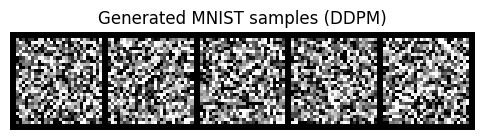

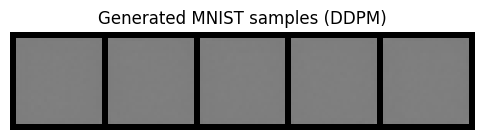

In [ ]:
# Visualize samples
grid = make_grid((t_grid + 1) / 2, nrow=5)   # back to [0,1] for display
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Generated MNIST samples (DDPM)")
plt.show()

# Visualize samples
grid = make_grid((s_grid + 1) / 2, nrow=5)   # back to [0,1] for display
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Generated MNIST samples (DDPM)")
plt.show()